# Hotel Booking Analysis

In [90]:
# Import additional necessary libraries for EDA and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

In [ ]:
# Load the cleaned hotel bookings dataset from the specified CSV file
df = pd.read_csv("../data/processed/eda_final_dataset.csv")

## 1. Dataset Overview

In [92]:
print("### DataFrame Head:")
display(df.head())

print("\n### DataFrame Info:")
df.info()

print("\n### DataFrame Description:")
display(df.describe())

### DataFrame Head:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,lead_time_category,stay_duration_category,price_tier,customer_segment,booking_type,season,is_peak_season,revenue_per_guest,average_night_value,clv_proxy
0,Resort Hotel,0,342.0,2015,July,27,1,0,0,2,...,Very Long Term (180D+),2-3 Nights,Budget,Non-Family,Standard Booking,Summer,1,0.0,0.0,0.0
1,Resort Hotel,0,347.0,2015,July,27,1,0,0,2,...,Very Long Term (180D+),2-3 Nights,Budget,Non-Family,Standard Booking,Summer,1,0.0,0.0,0.0
2,Resort Hotel,0,7.0,2015,July,27,1,0,1,1,...,Last Minute (0-7D),1 Night,Economy,Non-Family,Quick Trip,Summer,1,75.0,75.0,75.0
3,Resort Hotel,0,13.0,2015,July,27,1,0,1,1,...,Short Term (8-30D),1 Night,Economy,Non-Family,Standard Booking,Summer,1,75.0,75.0,75.0
4,Resort Hotel,0,14.0,2015,July,27,1,0,2,2,...,Short Term (8-30D),2-3 Nights,Standard,Non-Family,Standard Booking,Summer,1,98.0,49.0,294.0



### DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87219 entries, 0 to 87218
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87219 non-null  object 
 1   is_canceled                     87219 non-null  int64  
 2   lead_time                       87219 non-null  float64
 3   arrival_date_year               87219 non-null  int64  
 4   arrival_date_month              87219 non-null  object 
 5   arrival_date_week_number        87219 non-null  int64  
 6   arrival_date_day_of_month       87219 non-null  int64  
 7   stays_in_weekend_nights         87219 non-null  int64  
 8   stays_in_week_nights            87219 non-null  int64  
 9   adults                          87219 non-null  int64  
 10  children                        87219 non-null  float64
 11  babies                          87219 non-null  int64  
 12  country    

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,total_guests,total_revenue,has_children,is_weekend_stay,has_special_requests,is_direct_booking,is_peak_season,revenue_per_guest,average_night_value,clv_proxy
count,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,...,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000
mean,0.275273,79.375308,2016.210344,26.834497,15.816141,1.004632,2.624027,1.879407,0.138915,0.010846,...,2.029168,388.602612,0.104369,0.598115,0.498011,0.139155,0.243995,197.421167,55.417395,499.413035
std,0.446654,83.735246,0.686055,13.669141,8.835721,1.027384,2.039828,0.621727,0.456291,0.113711,...,0.790153,338.325393,0.305741,0.490282,0.499999,0.346111,0.429492,183.375838,28.110202,454.346366
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,2.000000,153.000000,0.000000,0.000000,0.000000,0.000000,0.000000,85.245000,37.961250,189.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,2.000000,299.200000,0.000000,1.000000,0.000000,0.000000,0.000000,151.500000,50.000000,372.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,...,2.000000,504.000000,0.000000,1.000000,1.000000,0.000000,0.000000,248.000000,67.000000,648.000000
max,1.000000,347.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,55.000000,1764.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7590.000000,252.000000,2424.000000


## 2. Descriptive Statistics

In [93]:
print("### Summary Statistics for all numerical columns:")
display(df.describe())

print("### Summary Statistics for categorical columns:")
display(df.describe(include='object'))

### Summary Statistics for all numerical columns:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,total_guests,total_revenue,has_children,is_weekend_stay,has_special_requests,is_direct_booking,is_peak_season,revenue_per_guest,average_night_value,clv_proxy
count,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,...,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000,87219.000000
mean,0.275273,79.375308,2016.210344,26.834497,15.816141,1.004632,2.624027,1.879407,0.138915,0.010846,...,2.029168,388.602612,0.104369,0.598115,0.498011,0.139155,0.243995,197.421167,55.417395,499.413035
std,0.446654,83.735246,0.686055,13.669141,8.835721,1.027384,2.039828,0.621727,0.456291,0.113711,...,0.790153,338.325393,0.305741,0.490282,0.499999,0.346111,0.429492,183.375838,28.110202,454.346366
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,2.000000,153.000000,0.000000,0.000000,0.000000,0.000000,0.000000,85.245000,37.961250,189.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,2.000000,299.200000,0.000000,1.000000,0.000000,0.000000,0.000000,151.500000,50.000000,372.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,...,2.000000,504.000000,0.000000,1.000000,1.000000,0.000000,0.000000,248.000000,67.000000,648.000000
max,1.000000,347.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,55.000000,1764.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7590.000000,252.000000,2424.000000


### Summary Statistics for categorical columns:


,hotel,arrival_date_month,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,meal_type,country_name,lead_time_category,stay_duration_category,price_tier,customer_segment,booking_type,season
count,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219,87219
unique,2,12,178,8,5,9,11,3,4,3,926,5,17,5,5,4,2,5,4
top,City Hotel,August,Prt,Online Ta,Ta/To,A,A,No Deposit,Transient,Check-Out,2016-02-14,Bed & Breakfast,Portugal,Medium Term (31-90D),2-3 Nights,Premium,Non-Family,Standard Booking,Summer
freq,53272,11239,27351,51547,69022,56428,46278,86074,71858,63210,211,67897,27351,28622,34152,25552,78116,64269,29037


## 3. Cancellation Analysis

### 3.1 Compare Features vs Cancellation

In [94]:
print("Mean values of key features grouped by cancellation status:")
display(df.groupby('is_canceled')[['lead_time', 'total_revenue', 'average_daily_rate']].mean())

Mean values of key features grouped by cancellation status:


,lead_time,total_revenue,average_daily_rate
is_canceled,,,
0,69.753172,359.044159,101.821344
1,104.708109,466.423007,117.081466


### 3.2 Visual Analysis of Cancellation vs. Lead Time

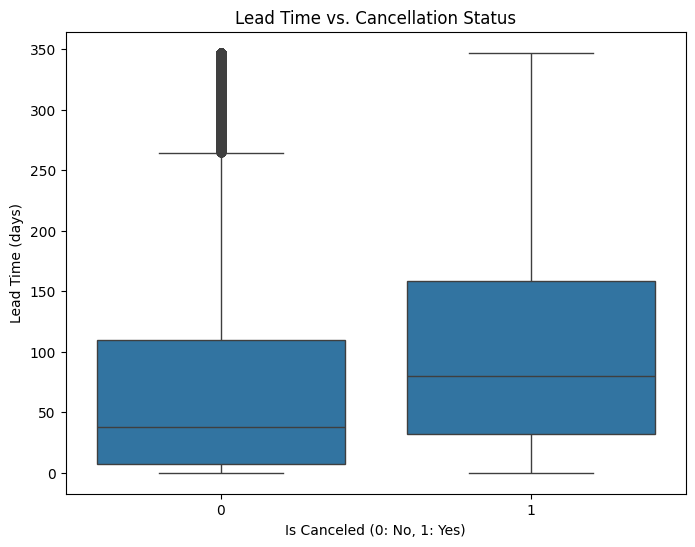

In [95]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time vs. Cancellation Status')
plt.xlabel('Is Canceled (0: No, 1: Yes)')
plt.ylabel('Lead Time (days)')
plt.show()

## 4. Revenue Analysis (Core Business Metric)

### 4.1 Total Revenue by Customer Segment

In [96]:
print("Aggregated total revenue by customer segment:")
display(df.groupby('customer_segment')['total_revenue'].agg(['mean','sum','count']))

Aggregated total revenue by customer segment:


,mean,sum,count
customer_segment,,,
Family,595.232199,5418398.71,9103
Non-Family,364.523690,28475132.54,78116


### 4.2 Visualization of Total Revenue by Customer Segment

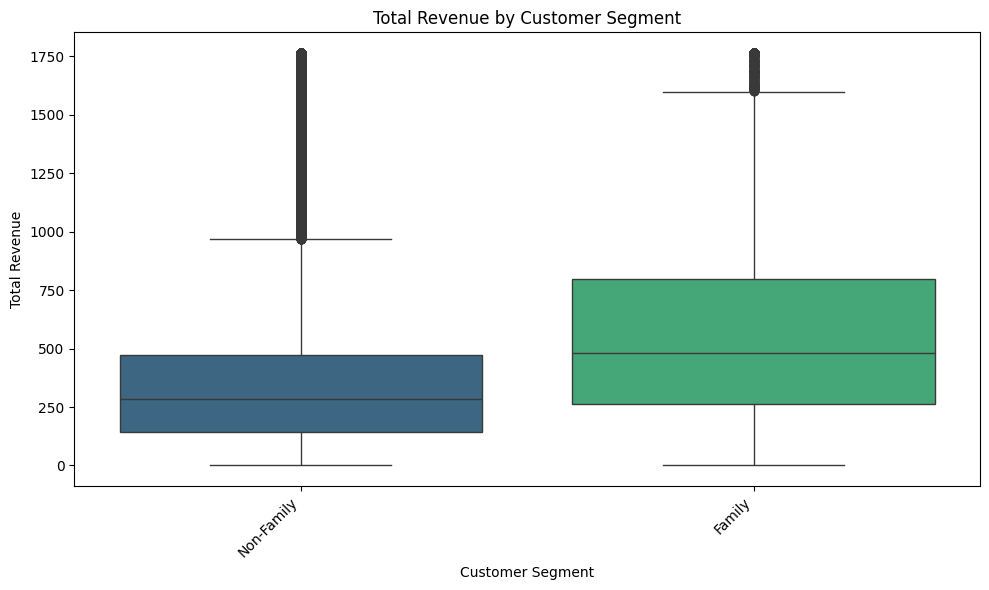

In [97]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='customer_segment', y='total_revenue', data=df, palette='viridis', hue='customer_segment', legend=False)
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Customer Behavior Analysis

### 5.1 Repeated vs. New Customers Analysis

In [98]:
print("Mean values of total revenue and total nights for repeated vs. new guests:")
display(df.groupby('is_repeated_guest')[['total_revenue', 'total_nights']].mean())

Mean values of total revenue and total nights for repeated vs. new guests:


,total_revenue,total_nights
is_repeated_guest,,
0,398.072359,3.695979
1,152.475626,1.950045


### 5.2 Visualization of Total Revenue for Repeated vs. New Customers

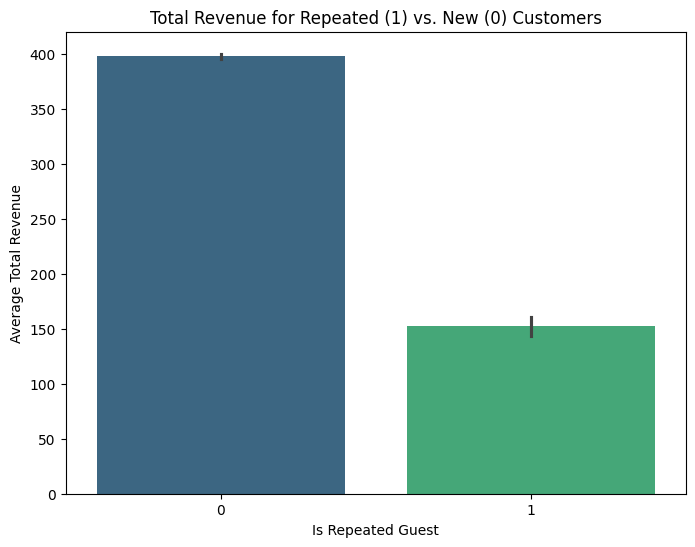

In [99]:
plt.figure(figsize=(8, 6))
sns.barplot(x='is_repeated_guest', y='total_revenue', data=df, palette='viridis', hue='is_repeated_guest', legend=False)
plt.title('Total Revenue for Repeated (1) vs. New (0) Customers')
plt.xlabel('Is Repeated Guest')
plt.ylabel('Average Total Revenue')
plt.show()

## 6. Booking & Stay Patterns

### 6.1 Weekend vs. Weekday Stays Analysis

In [100]:
print("Mean values of total revenue and total nights for weekend vs. weekday stays:")
display(df.groupby('is_weekend_stay')[['total_revenue', 'total_nights']].mean())

Mean values of total revenue and total nights for weekend vs. weekday stays:


,total_revenue,total_nights
is_weekend_stay,,
0,220.619162,2.063363
1,501.473890,4.680411


### 6.2 Stay Duration Categories Visualization

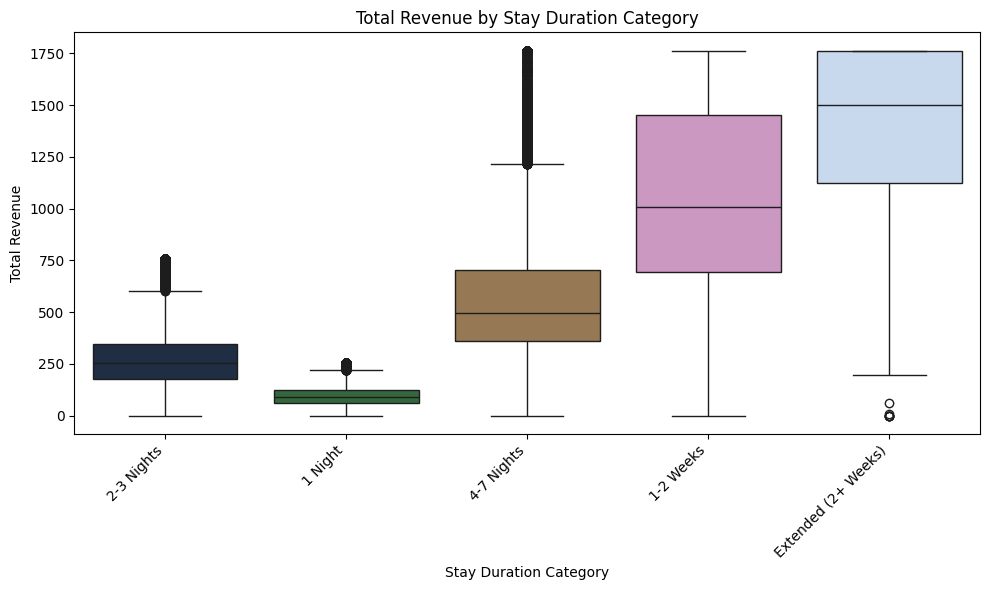

In [101]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='stay_duration_category', y='total_revenue', data=df, palette='cubehelix', hue='stay_duration_category', legend=False)
plt.title('Total Revenue by Stay Duration Category')
plt.xlabel('Stay Duration Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Market & Channel Analysis

### 7.1 Cancellation Rate per Market Segment

In [102]:
print("Cancellation Rate by Market Segment:")
display(df.groupby('market_segment')['is_canceled'].mean().reset_index().sort_values(by='is_canceled', ascending=False))

Cancellation Rate by Market Segment:


,market_segment,is_canceled
7,Undefined,1.000000
6,Online Ta,0.353891
4,Groups,0.270677
0,Aviation,0.199115
5,Offline Ta/To,0.148466
3,Direct,0.147453
1,Complementary,0.122832
2,Corporate,0.121306


###7.2 Statistical Test: Chi-Square Test for Market Segment and Cancellation

In [103]:
from scipy.stats import chi2_contingency

contingency_table_market = pd.crosstab(df['market_segment'], df['is_canceled'])
display(contingency_table_market)

chi2, p_value, dof, expected = chi2_contingency(contingency_table_market)
print(f"Chi-square statistic: {chi2:.4f}, P-value: {p_value:.4f}")
print("Conclusion: Significant dependency between market segment and cancellation status if P-value < 0.05.")

is_canceled,0,1
market_segment,,
Aviation,181,45
Complementary,607,85
Corporate,3687,509
Direct,10043,1737
Groups,3589,1332
Offline Ta/To,11798,2057
Online Ta,33305,18242
Undefined,0,2


Chi-square statistic: 4270.0350, P-value: 0.0000
Conclusion: Significant dependency between market segment and cancellation status if P-value < 0.05.


## 8. Pricing Strategy Analysis

### 8.1 Price Tier Impact

In [104]:
print("Mean cancellation rate and total revenue by price tier:")
display(df.groupby('price_tier')[['is_canceled', 'total_revenue']].mean())

Mean cancellation rate and total revenue by price tier:


,is_canceled,total_revenue
price_tier,,
Budget,0.175826,175.501474
Economy,0.258846,301.266707
Premium,0.343026,629.397768
Standard,0.303464,383.965288


### 8.2 ADR vs. Cancellation Status

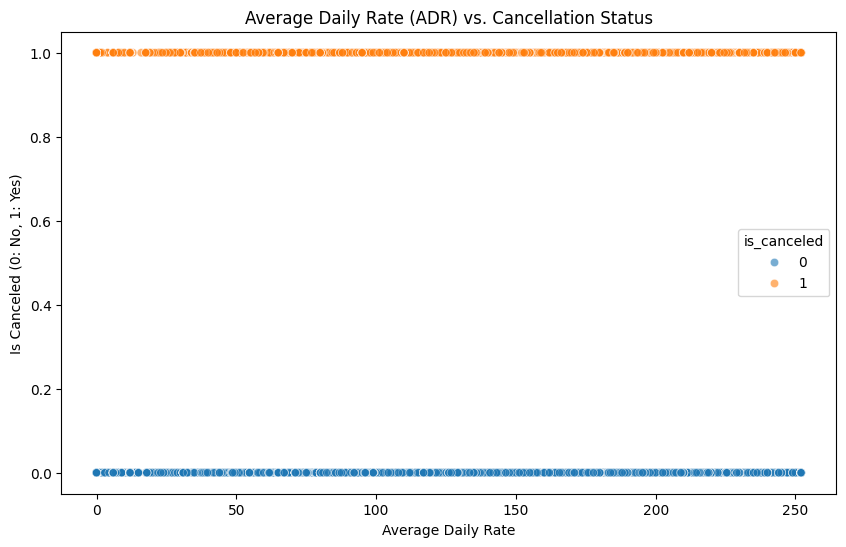

In [105]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='average_daily_rate', y='is_canceled', data=df, alpha=0.6, hue='is_canceled')
plt.title('Average Daily Rate (ADR) vs. Cancellation Status')
plt.xlabel('Average Daily Rate')
plt.ylabel('Is Canceled (0: No, 1: Yes)')
plt.show()

## 9. Correlation Analysis (Important for Numeric Features)

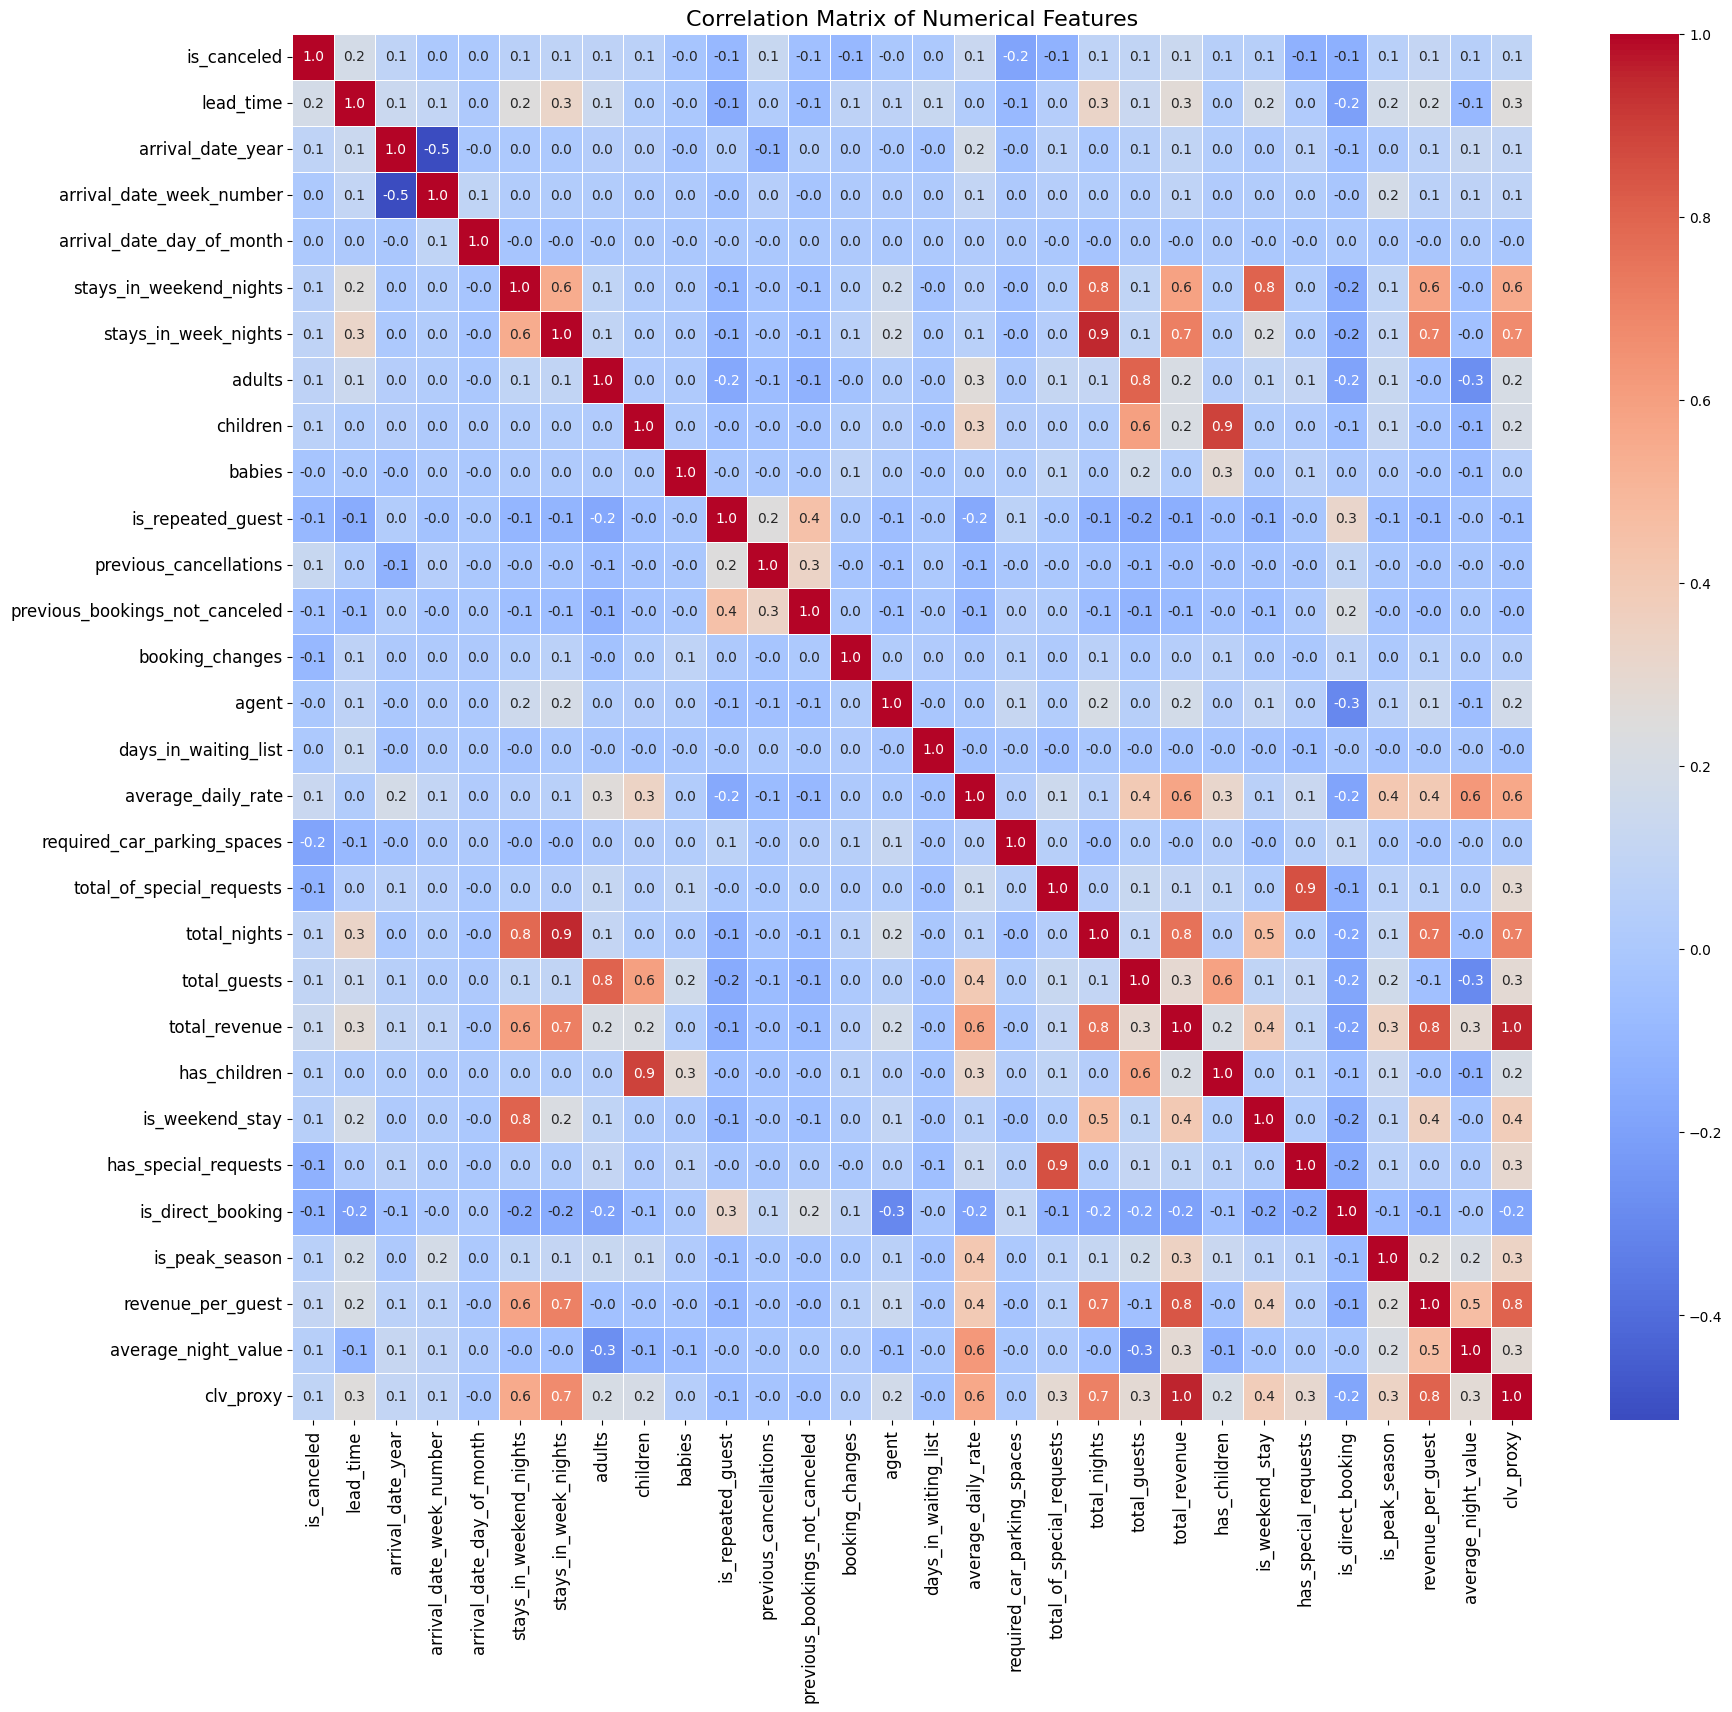

In [106]:
plt.figure(figsize=(20, 18)) # Increased figure size
# Calculate the correlation matrix for numerical features
correlation_matrix = df.select_dtypes(include=np.number).corr()
# Plot a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=.5, annot_kws={'fontsize': 10}) # Adjusted fmt and annot_kws
plt.title('Correlation Matrix of Numerical Features', fontsize=16) # Increased title font size for better visibility
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

## 10. Outlier Impact on Revenue

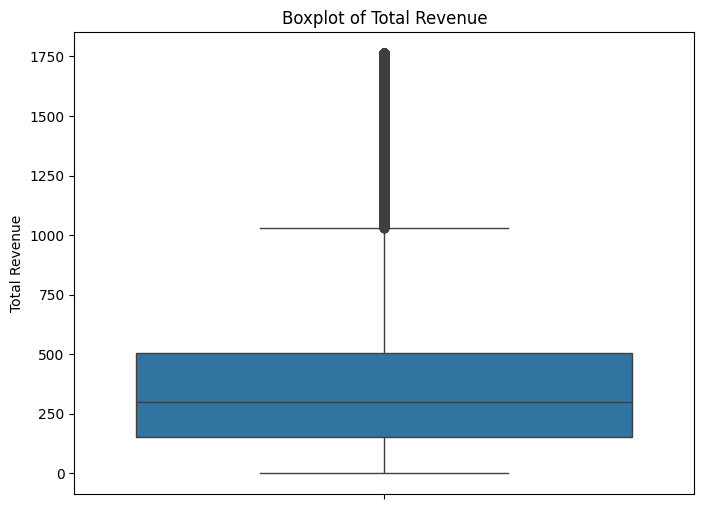

In [107]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='total_revenue', data=df)
plt.title('Boxplot of Total Revenue')
plt.ylabel('Total Revenue')
plt.show()

## 11. Seasonal Analysis

Mean total revenue and cancellation rate by season:


,total_revenue,is_canceled
season,,
Fall,317.967304,0.233403
Spring,333.579577,0.281362
Summer,556.245780,0.315838
Winter,246.884926,0.240962


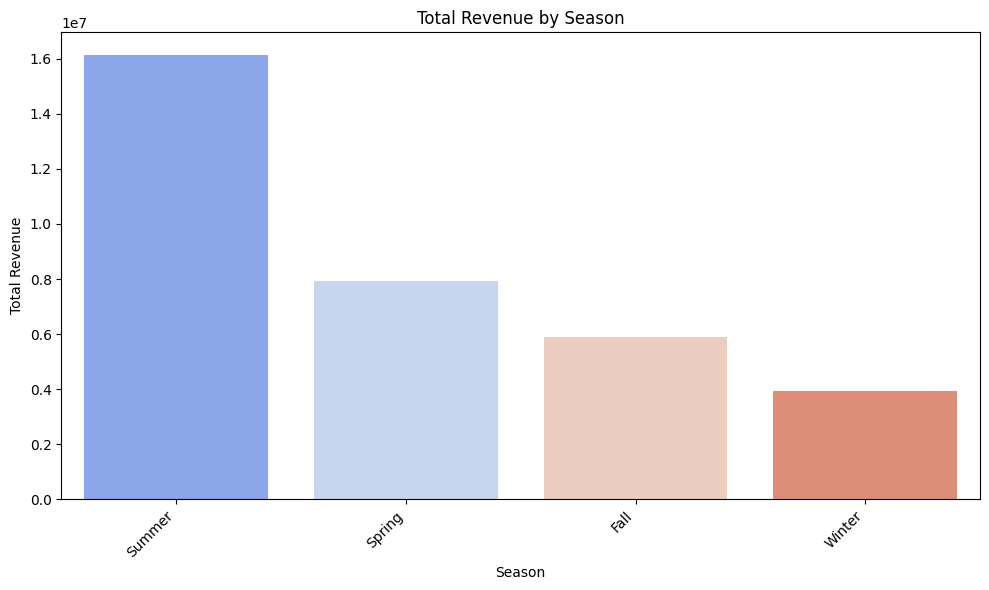

In [108]:
print("Mean total revenue and cancellation rate by season:")
display(df.groupby('season')[['total_revenue', 'is_canceled']].mean())

plt.figure(figsize=(10, 6))
revenue_by_season = df.groupby('season')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False)
sns.barplot(x='season', y='total_revenue', data=revenue_by_season, palette='coolwarm', hue='season', legend=False)
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Advanced (Lead-Level) Analysis

### 12.1 CLV Analysis

In [109]:
print("Mean CLV proxy by customer segment:")
display(df.groupby('customer_segment')['clv_proxy'].mean())

Mean CLV proxy by customer segment:


,clv_proxy
customer_segment,
Family,768.829949
Non-Family,468.017391


### 12.2 Revenue per Guest

In [110]:
print("Mean revenue per guest by customer type:")
display(df.groupby('customer_type')['revenue_per_guest'].mean())

Mean revenue per guest by customer type:


,revenue_per_guest
customer_type,
Contract,270.697027
Group,139.540407
Transient,198.185518
Transient-Party,175.741147


## 13. Group-wise Analysis

### 13.1 Cancellation Rate by Hotel Type

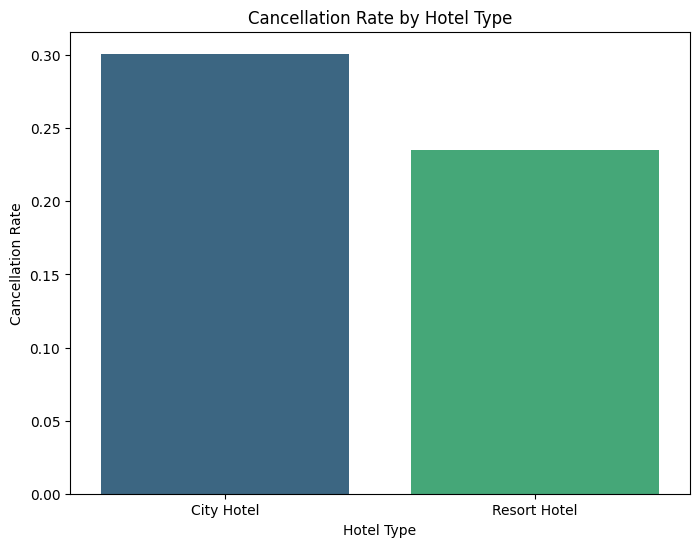

In [111]:
plt.figure(figsize=(8, 6))
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean().reset_index()
sns.barplot(x='hotel', y='is_canceled', data=cancel_by_hotel, palette='viridis', hue='hotel', legend=False)
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate')
plt.show()

### 13.2 Cancellation Rate by Market Segment

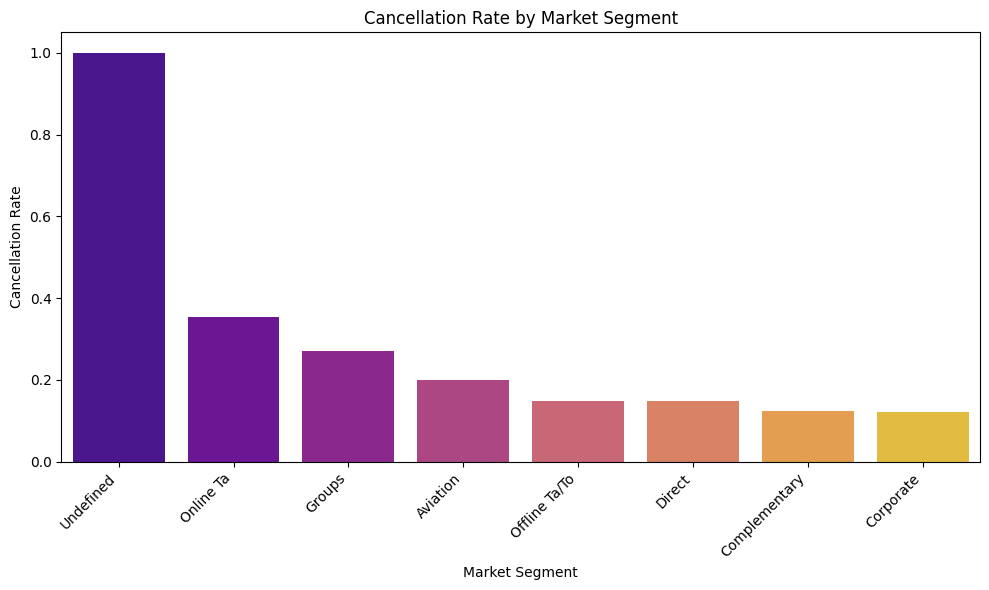

In [112]:
plt.figure(figsize=(10, 6))
cancel_by_market = df.groupby('market_segment')['is_canceled'].mean().reset_index().sort_values(by='is_canceled', ascending=False)
sns.barplot(x='market_segment', y='is_canceled', data=cancel_by_market, palette='plasma', hue='market_segment', legend=False)
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 13.3 ADR by Customer Type

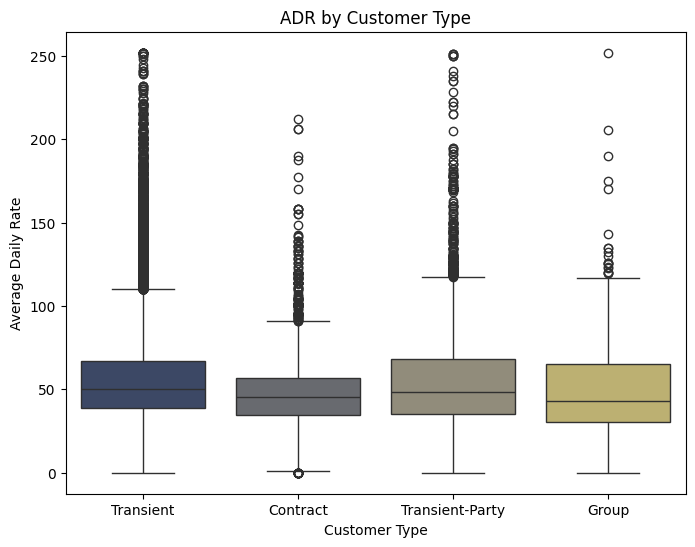

In [113]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='customer_type', y='average_night_value', data=df, palette='cividis', hue='customer_type', legend=False)
plt.title('ADR by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Daily Rate')
plt.show()

## 14. Customer Segment Analysis

###14.1 Distribution of Customer Segments

Distribution of Customer Segments:


,count
customer_segment,
Non-Family,78116
Family,9103


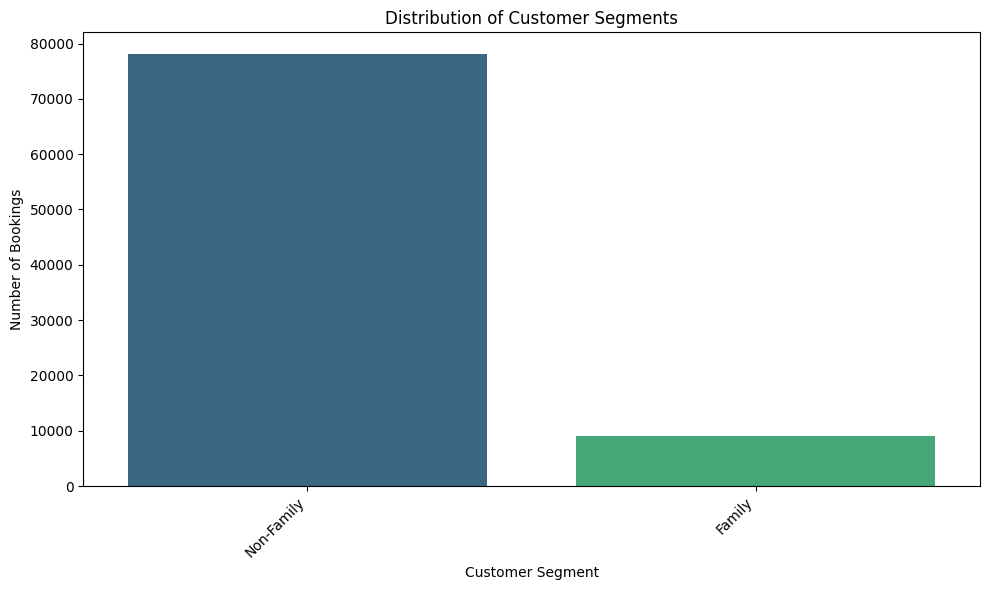

In [114]:
print('Distribution of Customer Segments:')
display(df['customer_segment'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='customer_segment', data=df, palette='viridis', hue='customer_segment', legend=False)
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 14.2 Cancellation Rate by Customer Segment

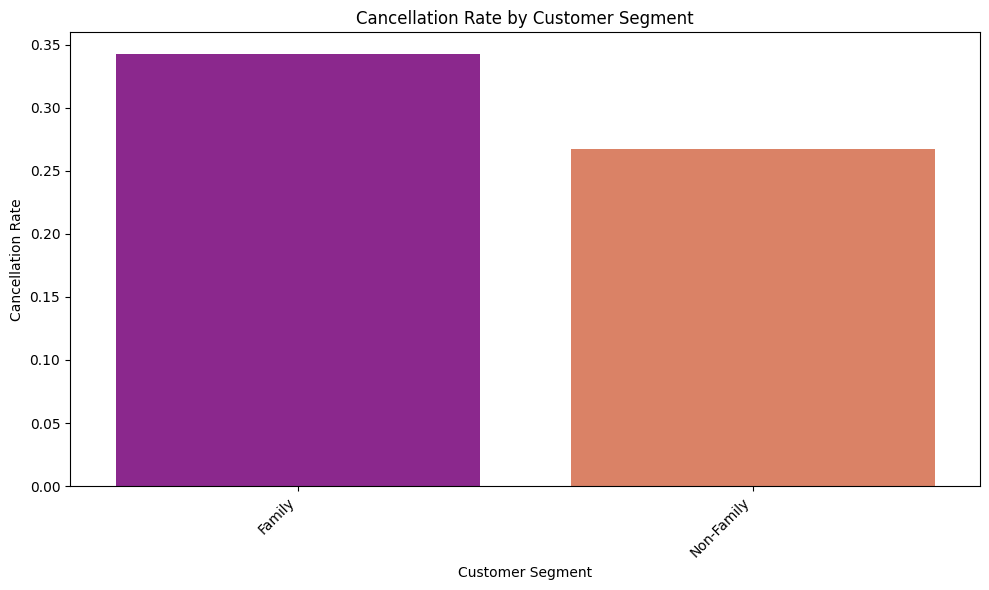

In [115]:
plt.figure(figsize=(10, 6))
cancel_by_segment = df.groupby('customer_segment')['is_canceled'].mean().reset_index().sort_values(by='is_canceled', ascending=False)
sns.barplot(x='customer_segment', y='is_canceled', data=cancel_by_segment, palette='plasma', hue='customer_segment', legend=False)
plt.title('Cancellation Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 15. Season-wise Analysis

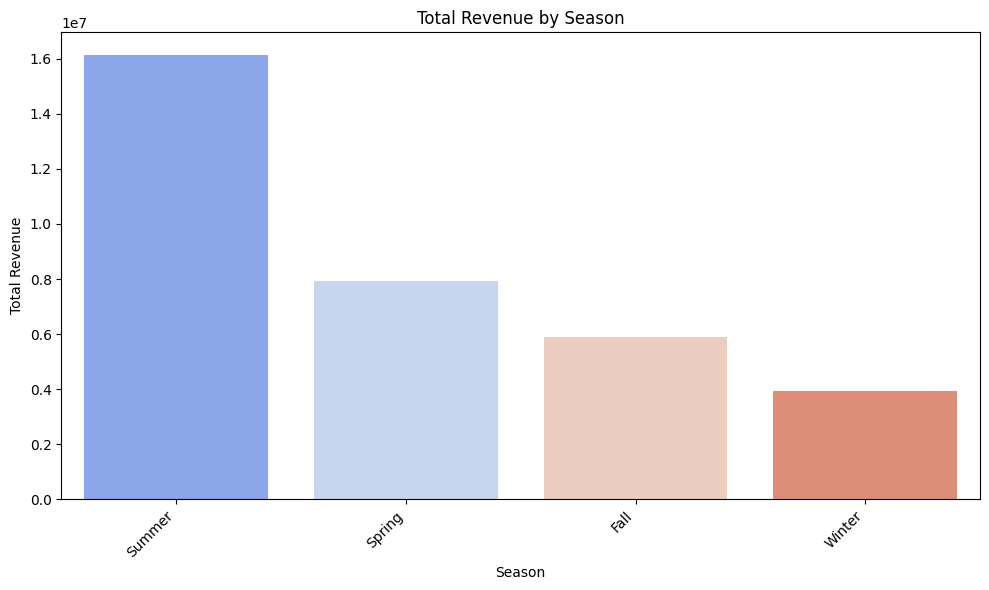

In [116]:
plt.figure(figsize=(10, 6))
revenue_by_season = df.groupby('season')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False)
sns.barplot(x='season', y='total_revenue', data=revenue_by_season, palette='coolwarm', hue='season', legend=False)
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 16. Cancellation Rate by Hotel Type

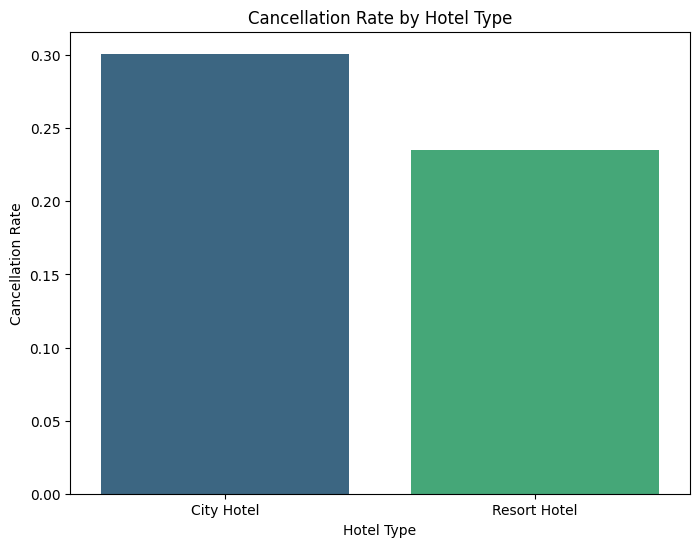

In [117]:
plt.figure(figsize=(8, 6))
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean().reset_index()
sns.barplot(x='hotel', y='is_canceled', data=cancel_by_hotel, palette='viridis', hue='hotel', legend=False)
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate')
plt.show()

## 17. Cancellation Rate by Market Segment

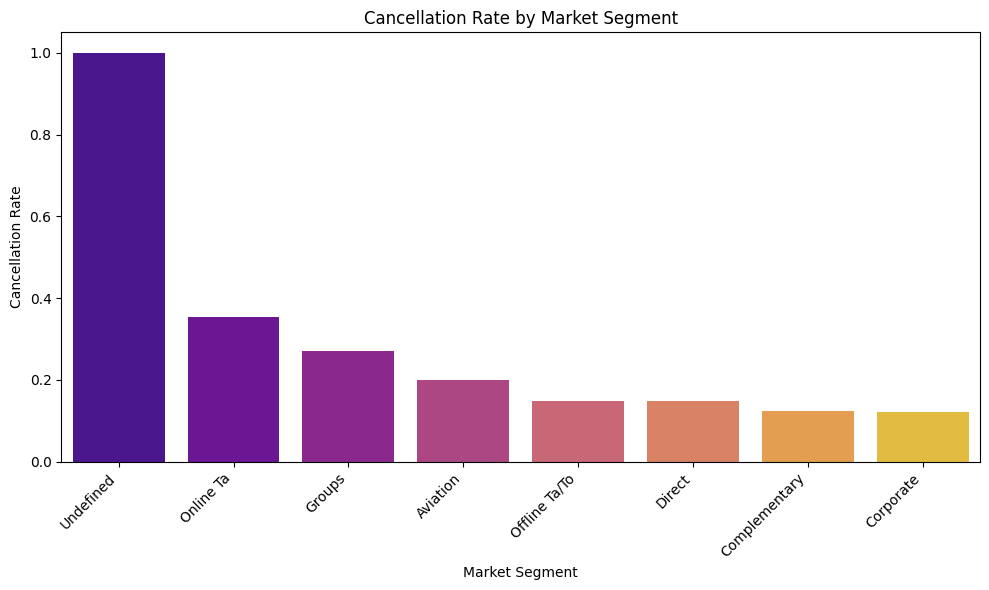

In [118]:
plt.figure(figsize=(10, 6))
cancel_by_market = df.groupby('market_segment')['is_canceled'].mean().reset_index().sort_values(by='is_canceled', ascending=False)
sns.barplot(x='market_segment', y='is_canceled', data=cancel_by_market, palette='plasma', hue='market_segment', legend=False)
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()